# Loading Text Data

In [1]:
# Create a small sample dataset.
import pandas as pd
 
data = {
    "text": [
        "This movie was fantastic",
        "I loved the acting",
        "The film was terrible",
        "Worst movie ever",
        "Amazing storyline",
        "I hated this movie"
    ],
    "label": [1, 1, 0, 0, 1, 0]
}
 
df = pd.DataFrame(data)
 
print(df.head())


                       text  label
0  This movie was fantastic      1
1        I loved the acting      1
2     The film was terrible      0
3          Worst movie ever      0
4         Amazing storyline      1


# Tokenization

In [2]:
# Convert text into token IDs.

from collections import Counter
 
all_words = []
 
for sentence in df["text"]:
    all_words.extend(sentence.lower().split())
 
vocab = {word: idx+1 for idx, word in enumerate(set(all_words))}
 
print(vocab)

{'ever': 1, 'loved': 2, 'worst': 3, 'amazing': 4, 'storyline': 5, 'movie': 6, 'fantastic': 7, 'the': 8, 'i': 9, 'terrible': 10, 'acting': 11, 'hated': 12, 'was': 13, 'this': 14, 'film': 15}


In [3]:
# Convert text to token sequences:

max_length = 6
 
def encode(sentence):
    tokens = [vocab[word] for word in sentence.lower().split()]
    
    if len(tokens) < max_length:
        tokens += [0]*(max_length-len(tokens))
        
    return tokens[:max_length]
 
X = [encode(text) for text in df["text"]]
 
print(X[0])
 

[14, 6, 13, 7, 0, 0]


# Building a Transformer Model

In [6]:
# Create a simple Transformer classifier.
import torch
import torch.nn as nn
 
class TransformerClassifier(nn.Module):
 
    def __init__(self,
                 vocab_size,
                 embed_dim=32,
                 num_heads=4):
 
        super().__init__()
 
        self.embedding = nn.Embedding(
            vocab_size,
            embed_dim
        )
 
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=num_heads,
            batch_first=True
        )
 
        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=2
        )
 
        self.fc = nn.Linear(embed_dim, 2)
 
    def forward(self, x):
 
        x = self.embedding(x)
 
        x = self.transformer(x)
 
        x = x.mean(dim=1)
 
        return self.fc(x)

In [7]:
# Create model
model = TransformerClassifier(
    vocab_size=len(vocab)+1
)
 
print(model)

TransformerClassifier(
  (embedding): Embedding(16, 32)
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=32, out_features=32, bias=True)
        )
        (linear1): Linear(in_features=32, out_features=2048, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=2048, out_features=32, bias=True)
        (norm1): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (fc): Linear(in_features=32, out_features=2, bias=True)
)


# Training the Model

In [8]:
# Prepare tensors
X_tensor = torch.tensor(X)
 
y_tensor = torch.tensor(
    df["label"].values
)
 
criterion = nn.CrossEntropyLoss()
 
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

[transformers] Disabling PyTorch because PyTorch >= 2.4 is required but found 2.2.2
[transformers] PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


In [9]:
# Training loop
epochs = 50
 
for epoch in range(epochs):
 
    optimizer.zero_grad()
 
    outputs = model(X_tensor)
 
    loss = criterion(
        outputs,
        y_tensor
    )
 
    loss.backward()
 
    optimizer.step()
 
    if epoch % 10 == 0:
        print(
            f"Epoch {epoch}, Loss: {loss.item():.4f}"
        )

Epoch 0, Loss: 0.8569
Epoch 10, Loss: 0.5189
Epoch 20, Loss: 0.1768
Epoch 30, Loss: 0.0328
Epoch 40, Loss: 0.0089


# Evaluating Performance

In [10]:
# Generate predictions
with torch.no_grad():
 
    outputs = model(X_tensor)
 
    predictions = torch.argmax(
        outputs,
        dim=1
    )
 
accuracy = (
    predictions == y_tensor
).float().mean()
 
print(
    "Accuracy:",
    accuracy.item()
)
 

Accuracy: 1.0


# Visualizing Attention Scores

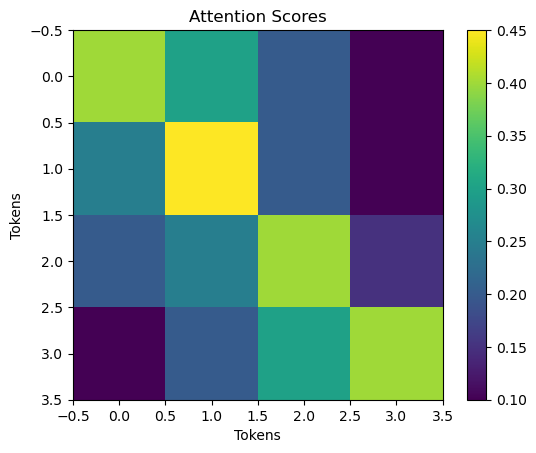

In [11]:
# Create a simple attention visualization.
import matplotlib.pyplot as plt
import numpy as np
 
attention = np.array([
    [0.40,0.30,0.20,0.10],
    [0.25,0.45,0.20,0.10],
    [0.20,0.25,0.40,0.15],
    [0.10,0.20,0.30,0.40]
])
 
plt.imshow(attention)
 
plt.colorbar()
 
plt.title(
    "Attention Scores"
)
 
plt.xlabel("Tokens")
plt.ylabel("Tokens")
 
plt.show()